In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:
sns.set_style("whitegrid")



In [4]:
df = pd.read_csv("Advertising.csv")

In [5]:
print(df.head())

   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


In [7]:
print(df.isnull().sum())

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print(df.describe())

       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


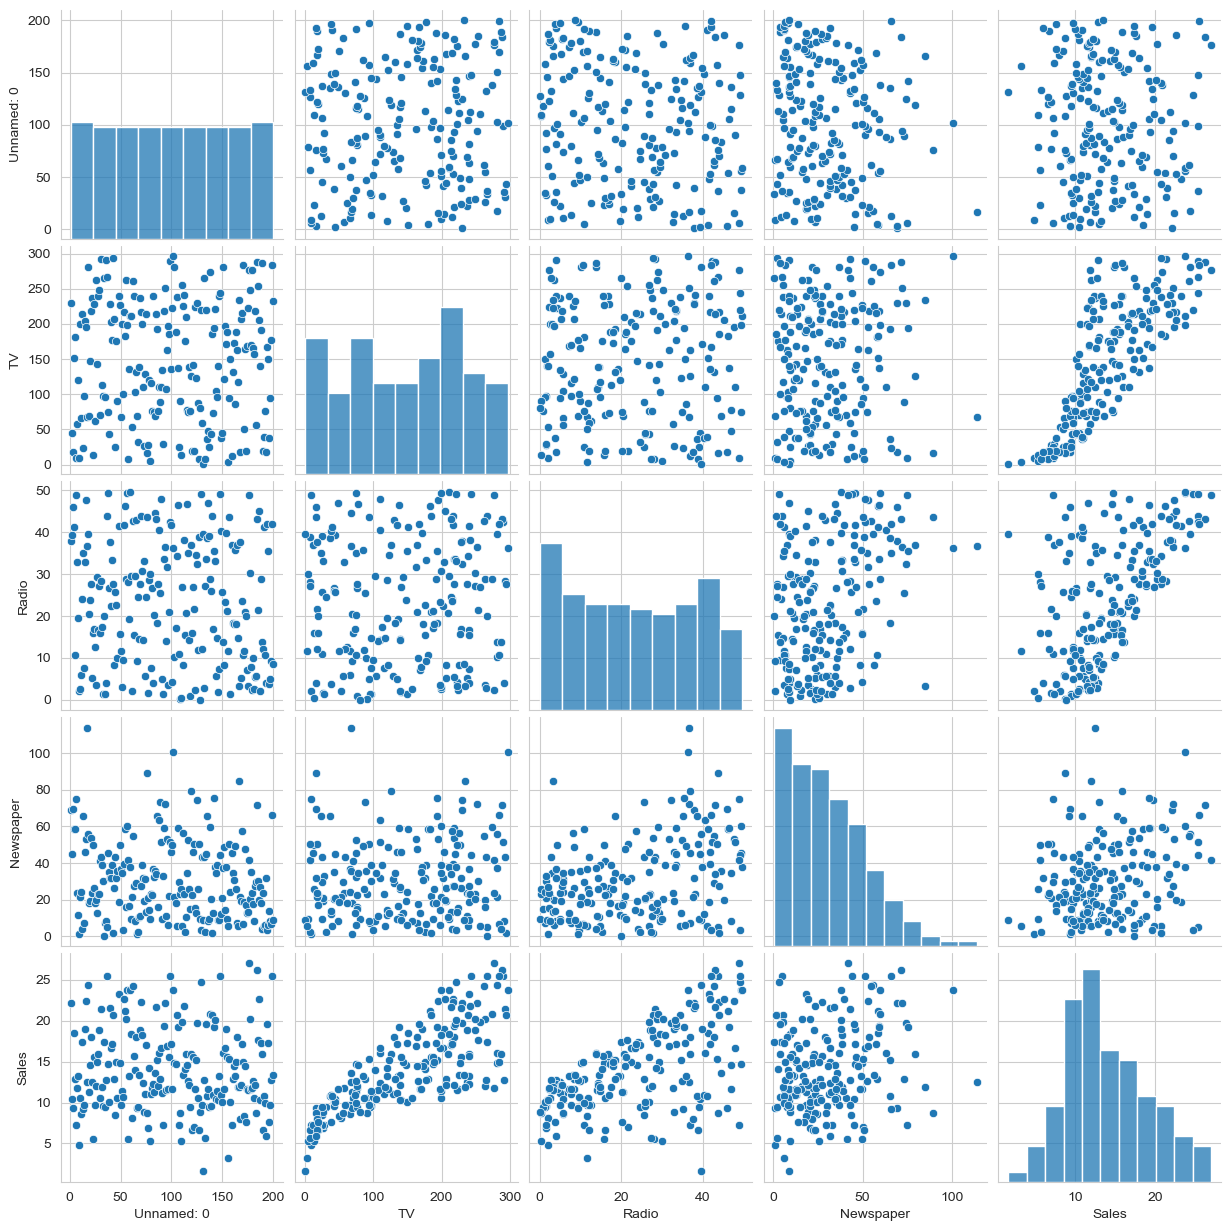

In [10]:
sns.pairplot(df)

In [11]:
plt.show()

<Axes: >

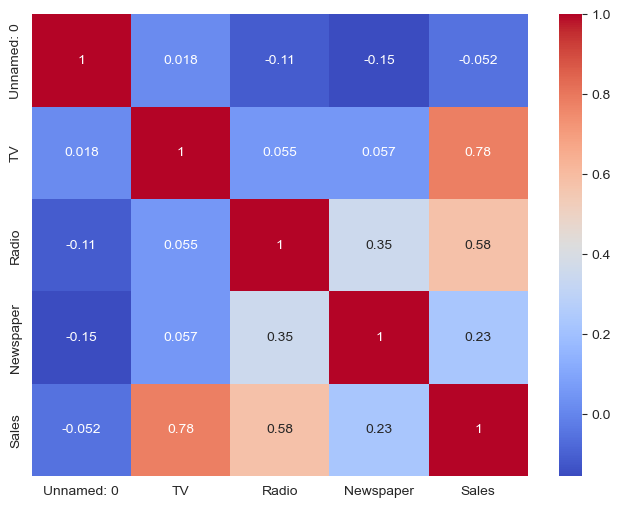

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

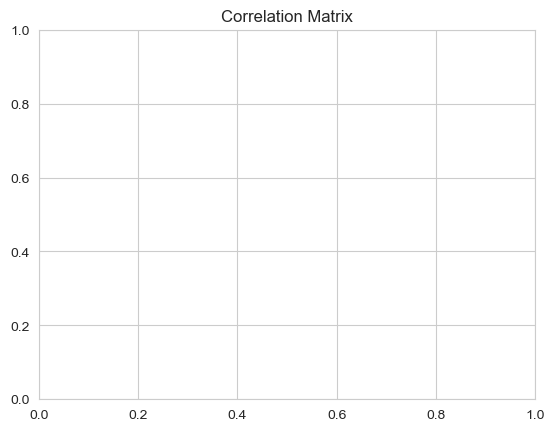

In [13]:
plt.title("Correlation Matrix")

plt.show()

<Axes: xlabel='TV', ylabel='Sales'>

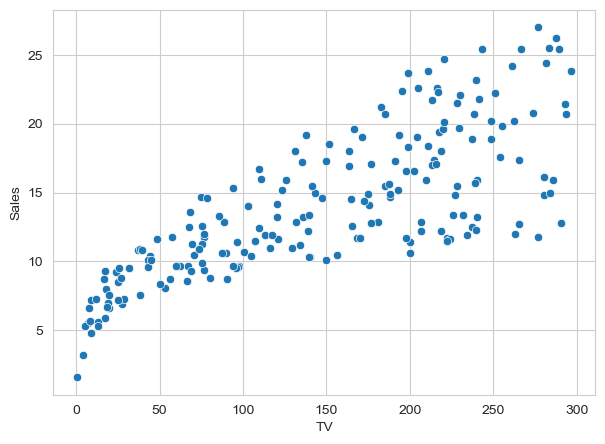

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales'
)

Text(0.5, 1.0, 'TV Advertising vs Sales')

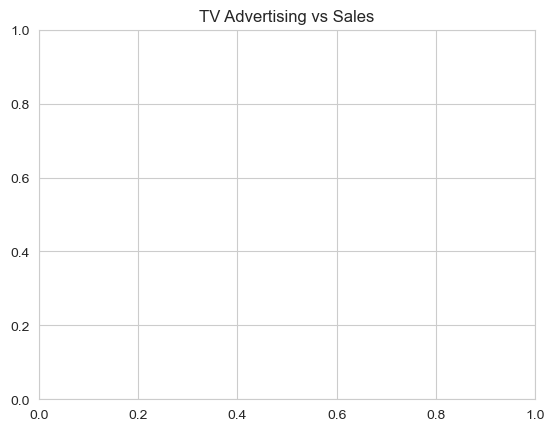

In [15]:
plt.title("TV Advertising vs Sales")

<Axes: xlabel='Radio', ylabel='Sales'>

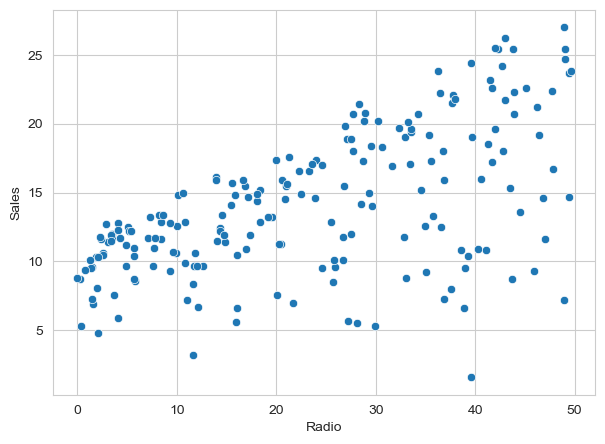

In [16]:
plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales'
)

Text(0.5, 1.0, 'Radio Advertising vs Sales')

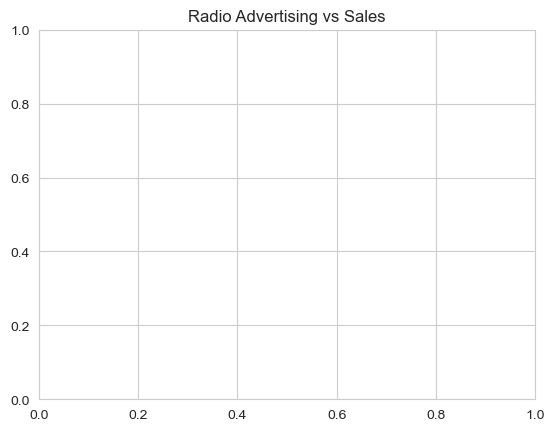

In [17]:
plt.title("Radio Advertising vs Sales")

<Axes: xlabel='Newspaper', ylabel='Sales'>

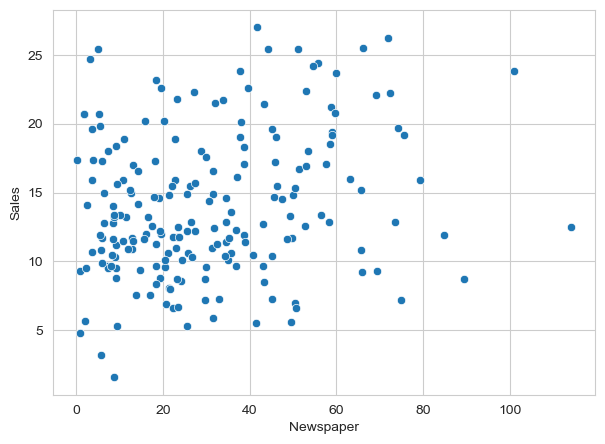

In [18]:
plt.show()

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='Newspaper',
    y='Sales'
)

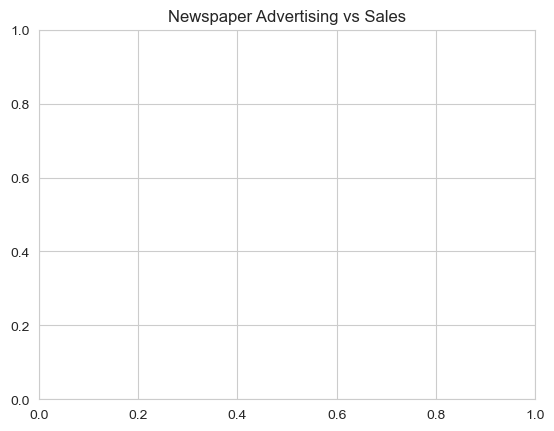

In [19]:
plt.title("Newspaper Advertising vs Sales")

plt.show()

In [20]:
X = df[['TV','Radio','Newspaper']]

y = df['Sales']

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [21]:
model = LinearRegression()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [22]:
print("\nModel Evaluation\n")


Model Evaluation



In [23]:
print("MAE :",mean_absolute_error(y_test,y_pred))


MAE : 1.4607567168117606


In [24]:
print("MSE :",mean_squared_error(y_test,y_pred))

MSE : 3.1740973539761055


In [25]:
print("RMSE :",mean_squared_error(y_test,y_pred)**0.5)


RMSE : 1.7815996615334506


In [26]:
print("R2 Score :",r2_score(y_test,y_pred))


R2 Score : 0.899438024100912


In [28]:
plt.figure(figsize=(7,5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

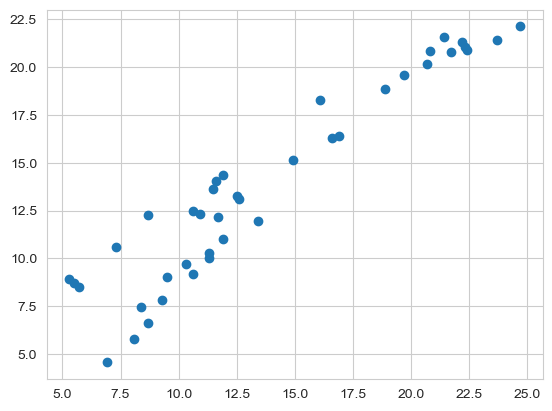

In [29]:
plt.scatter(y_test,y_pred)


Text(0.5, 0, 'Actual Sales')

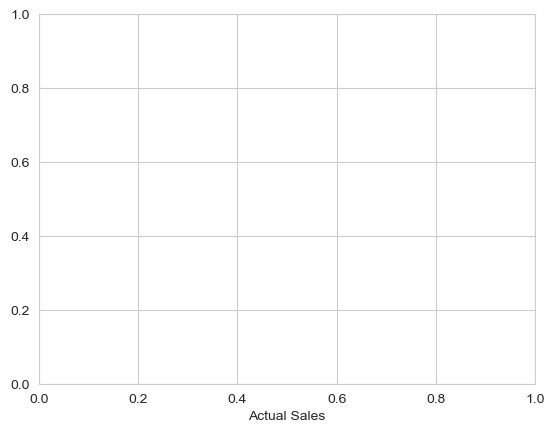

In [30]:
plt.xlabel("Actual Sales")


Text(0, 0.5, 'Predicted Sales')

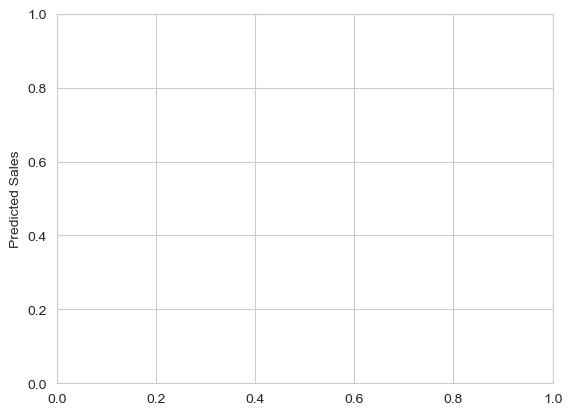

In [31]:
plt.ylabel("Predicted Sales")

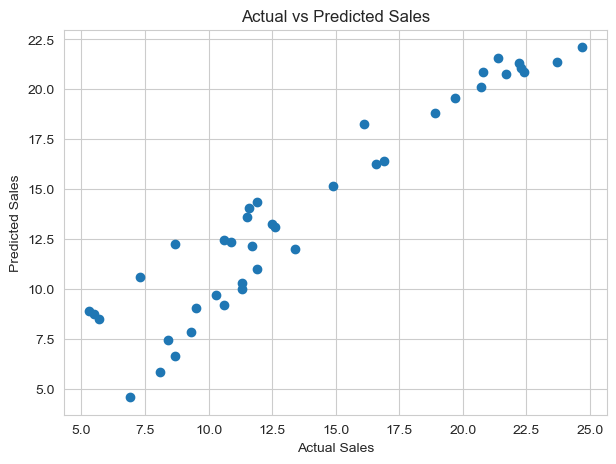

In [32]:
plt.figure(figsize=(7,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [34]:
sample = [[230.1,37.8,69.2]]

In [36]:
prediction = model.predict(sample)

print("\nPredicted Sales:",prediction[0])

importance = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':model.coef_
})



Predicted Sales: 20.6139714701563


C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [37]:

print("\nFeature Importance")


Feature Importance


In [38]:
print(importance)


     Feature  Coefficient
0         TV     0.044730
1      Radio     0.189195
2  Newspaper     0.002761


<Axes: xlabel='Coefficient', ylabel='Feature'>

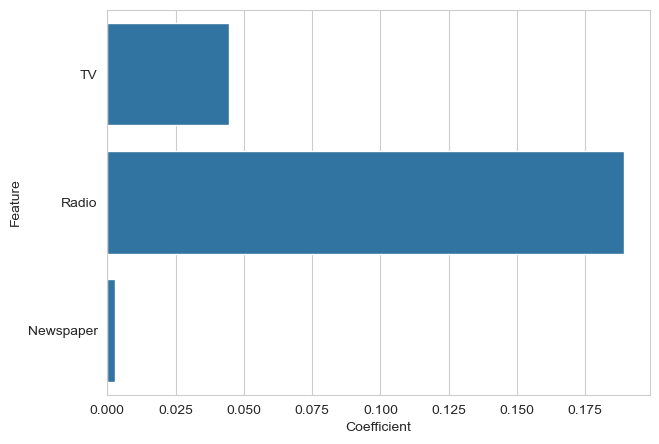

In [39]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature'
)


Text(0.5, 1.0, 'Advertising Channel Importance')

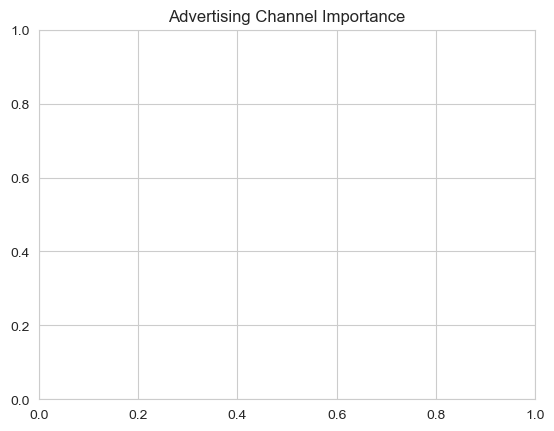

In [40]:
plt.title("Advertising Channel Importance")

In [41]:
plt.show()

print("\nKEY INSIGHTS")


KEY INSIGHTS


In [42]:
print("1. TV advertising has the strongest impact on sales.")

1. TV advertising has the strongest impact on sales.


In [43]:
print("2. Radio advertising positively influences sales.")

2. Radio advertising positively influences sales.


In [44]:
print("3. Newspaper advertising contributes less compared to TV and Radio.")

3. Newspaper advertising contributes less compared to TV and Radio.


In [45]:
print("4. Increasing investment in high-performing channels can improve revenue.")

4. Increasing investment in high-performing channels can improve revenue.


In [46]:
print("5. The regression model can help forecast future sales based on advertising budgets.")

5. The regression model can help forecast future sales based on advertising budgets.
